Lysozyme in Water Tutorial

#The original tutorial can be reached by http://www.mdtutorials.com/gmx/lysozyme/index.html

In [1]:
"""Is important to import all the libraries you may use in your program,eg: openmm as the execution, matplotlib for plotting, yaml as a saving format, etc.
This libraries are currently on your conda environment (gromacs) and can be seen in the terminal using the command -conda list-"""

from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
import numpy as np
import matplotlib.pyplot as plt


Use # to silence code

In [2]:
"You must have the crystal structure and now we will delete the waters from it"

#Specify paths
lyz='../structures/1aki.pdb'
clean_lyz='../structures/1aki_clean.pdb'

pdb=PDBFile(lyz)

modeller = Modeller(pdb.topology, pdb.positions)
modeller.deleteWater()

In [5]:
"""Specify the forcefield"""

forcefield = ForceField('charmm36.xml', 'charmm36/spce.xml')
#And add missing hydrogens
residues=modeller.addHydrogens(forcefield)

In [6]:
"""This command creates a box that has edges at least 1nm away from the solute and fills it with water.
 Addionally it adds ions to make the system charge neutral."""

modeller.addSolvent(forcefield, padding=1.0*nanometer)

In [ ]:
"""Create the integrator, and combine the integrator and system to create the Simulation object"""
system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME, nonbondedCutoff=1.0*nanometer, constraints=HBonds)
integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
simulation = Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

In [ ]:
"""Important: Minimize the energy"""
print("Minimizing energy")
simulation.minimizeEnergy()

In [ ]:
#Reporters:
simulation.reporters.append(PDBReporter('OpenMM_output.pdb', 1000))
simulation.reporters.append(StateDataReporter(stdout, 1000, step=True,
        potentialEnergy=True, temperature=True, volume=True))
simulation.reporters.append(StateDataReporter("OpenMM_md_log.txt", 100, step=True,
        potentialEnergy=True, temperature=True, volume=True))

In [ ]:
"Run the simulation"
print("Running NVT")
simulation.step(10000)

In [ ]:
system.addForce(MonteCarloBarostat(1*bar, 300*kelvin))
simulation.context.reinitialize(preserveState=True)


print("Running NPT")
simulation.step(10000)

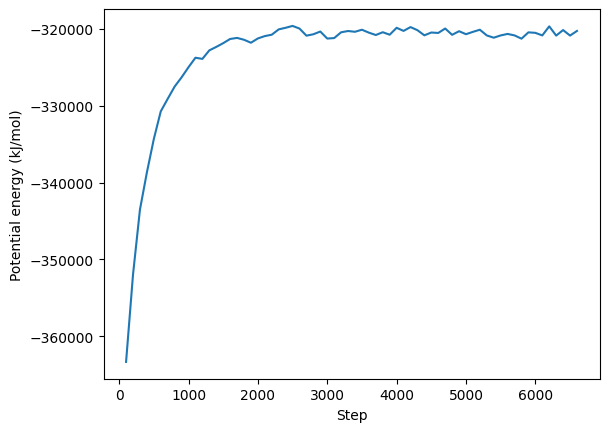

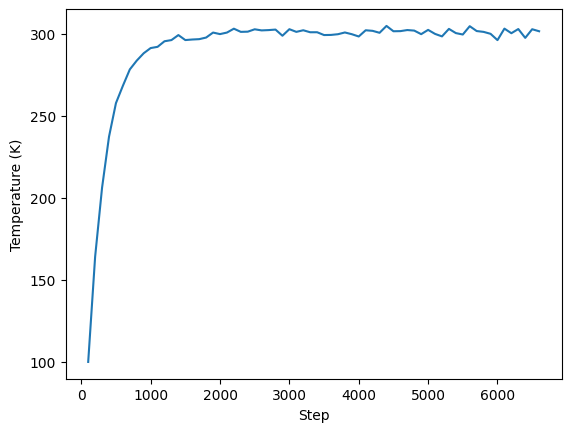

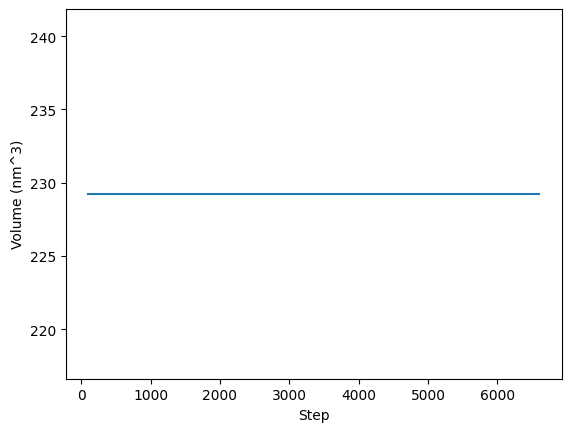

In [7]:
data = np.loadtxt("OpenMM_md_log.txt", delimiter=',')

step = data[:,0]
potential_energy = data[:,1]
temperature = data[:,2]
volume = data[:,3]

plt.plot(step, potential_energy)
plt.xlabel("Step")
plt.ylabel("Potential energy (kJ/mol)")
plt.show()
plt.plot(step, temperature)
plt.xlabel("Step")
plt.ylabel("Temperature (K)")
plt.show()
plt.plot(step, volume)
plt.xlabel("Step")
plt.ylabel("Volume (nm^3)")
plt.show()